<a href="https://colab.research.google.com/github/aycaaydin021-byte/Projeler/blob/main/Kapnografi_Analizi_adl%C4%B1_not_defterinin_kopyas%C4%B1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import os
os.listdir('/content')


['.config', 'classification_co2_data.csv', 'sample_data']

In [ ]:
import pandas as pd

df = pd.read_csv('/content/classification_co2_data.csv')

In [ ]:
df.head()

,1.18,1.19,1.2,1.22,1.24,1.25,1.26,1.28,1.3,1.31,...,0.18.242,0.18.243,0.18.244,0.17.239,0.17.240,0.17.241,0.17.242,0.17.243,0.17.244,0.16.513
0,4.61,4.61,4.62,4.62,4.62,4.63,4.64,4.64,4.64,4.65,...,0.41,0.41,0.40,0.40,0.40,0.39,0.39,0.39,0.38,0.38
1,5.54,5.54,5.54,5.54,5.54,5.55,5.55,5.55,5.55,5.55,...,0.60,0.59,0.58,0.58,0.57,0.57,0.56,0.56,0.55,0.55
2,0.30,0.30,0.30,0.30,0.31,0.31,0.32,0.32,0.33,0.34,...,4.46,4.46,4.46,4.45,4.45,4.45,4.45,4.45,4.45,4.44
3,3.28,3.27,3.26,3.25,3.24,3.23,3.22,3.21,3.21,3.20,...,5.67,5.67,5.68,5.68,5.68,5.68,5.68,5.68,5.69,5.69
4,3.66,3.66,3.66,3.66,3.67,3.67,3.67,3.68,3.68,3.68,...,7.48,7.48,7.48,7.48,7.49,7.49,7.49,7.49,7.49,7.49


In [ ]:
df.shape

(178, 36001)

In [ ]:
df.info()
df.isnull().sum().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 178 entries, 0 to 177
Columns: 36001 entries, 1.18 to 0.16.513
dtypes: float64(36001)
memory usage: 48.9 MB


np.int64(0)

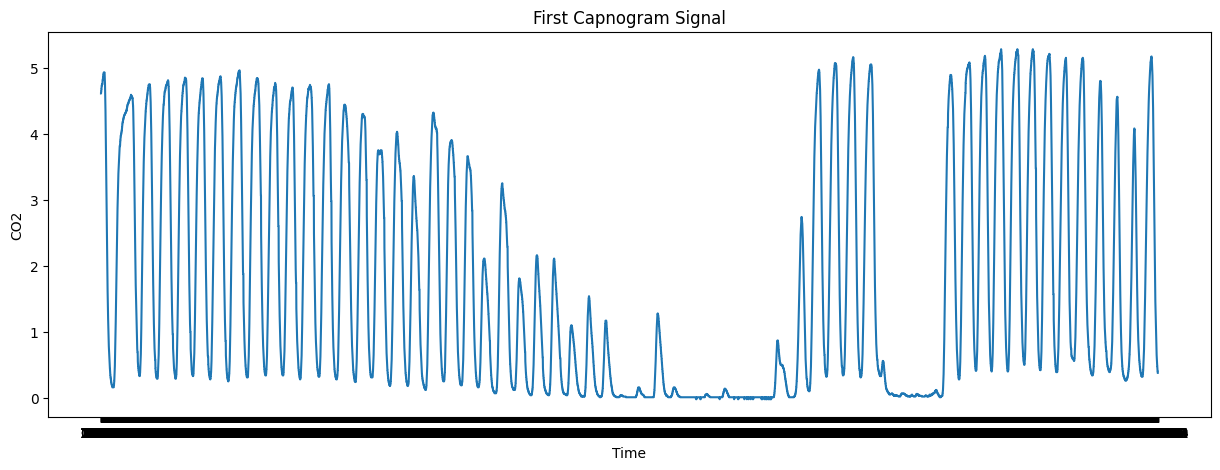

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15,5))
plt.plot(df.iloc[0])
plt.title("First Capnogram Signal")
plt.xlabel("Time")
plt.ylabel("CO2")
plt.show()


In [ ]:
features = pd.DataFrame()

features['mean'] = df.mean(axis=1)
features['std'] = df.std(axis=1)
features['max'] = df.max(axis=1)
features['min'] = df.min(axis=1)
features['median'] = df.median(axis=1)

In [ ]:
features.head()

,mean,std,max,min,median
0,1.756191,1.779270,5.28,-0.02,0.94
1,3.380706,2.019486,5.77,0.32,3.92
2,2.811573,1.820471,5.80,0.05,2.99
3,2.788951,2.041750,6.00,0.04,2.90
4,5.826083,2.443737,9.35,0.35,6.84


In [ ]:
features['label'] = (features['mean'] > 2.5).astype(int)
features['label'].value_counts()

,count
label,
1,122
0,56


In [ ]:
from sklearn.model_selection import train_test_split

X = features.drop('label', axis=1)
y = features['label']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [ ]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier()

model.fit(X_train, y_train)

RandomForestClassifier()

In [ ]:
from sklearn.metrics import accuracy_score

y_pred = model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 1.0


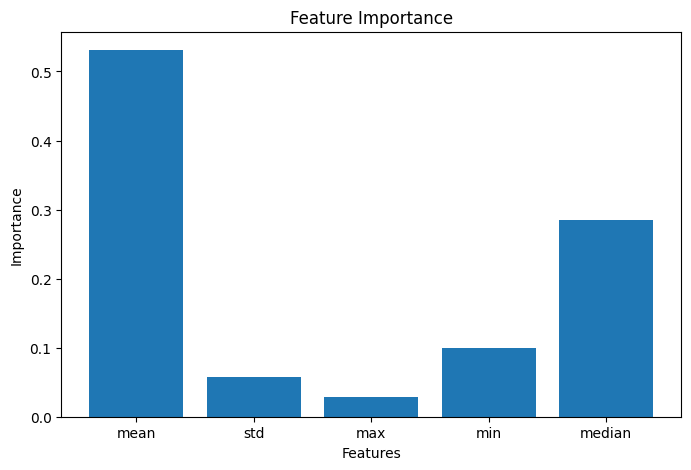

In [ ]:
import matplotlib.pyplot as plt

importance = model.feature_importances_
feature_names = X.columns

plt.figure(figsize=(8,5))
plt.bar(feature_names, importance)

plt.xlabel("Features")
plt.ylabel("Importance")
plt.title("Feature Importance")

plt.show()

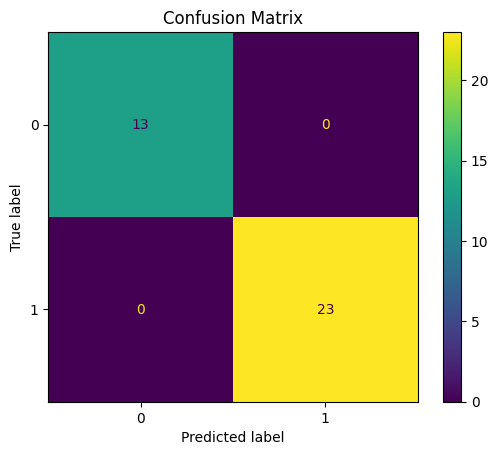

In [ ]:
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)

disp.plot()

plt.title("Confusion Matrix")
plt.show()

In [ ]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        13
           1       1.00      1.00      1.00        23

    accuracy                           1.00        36
   macro avg       1.00      1.00      1.00        36
weighted avg       1.00      1.00      1.00        36

